# Nome: Neivan Júnior Alves Costa
# Matrícula: Aluno especial

## Import all packages need in the cell below

In [31]:
using LinearAlgebra
using Printf
using ForwardDiff
using Optim
using NLsolve
using Plots
using JuMP
using HiGHS

default(linewidth = 2, markerstrokewidth = 0)

## FONC example

Plot the graphics of $f(x) = (x_1 - 3)^2 + (x_2 + 4)^2$

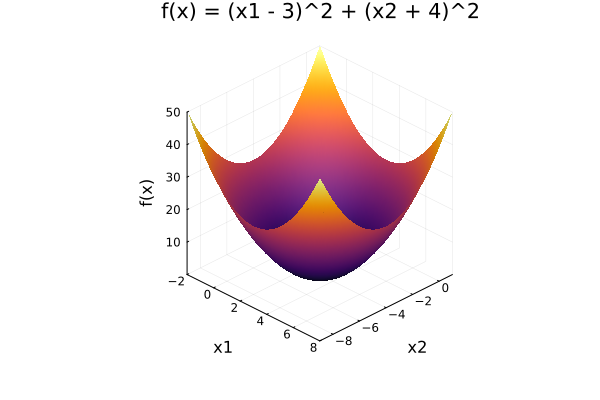

In [32]:
f_example(x1, x2) = (x1 - 3)^2 + (x2 + 4)^2

x1_grid = range(-2, 8; length = 100)
x2_grid = range(-9, 1; length = 100)
Z_example = [f_example(a, b) for b in x2_grid, a in x1_grid]

surface(
    x1_grid,
    x2_grid,
    Z_example;
    xlabel = "x1",
    ylabel = "x2",
    zlabel = "f(x)",
    title = "f(x) = (x1 - 3)^2 + (x2 + 4)^2",
    camera = (45, 30),
    legend = false,
)

## Solving the FONC

Given the function $z = (x_1 - 1)^4 + (x_2 - 2)^4$:

* using the optim.jl package, find the minimum of z.
* using the NLsolve.jl package, solve the FONC problem for this function

In [33]:
z(x) = (x[1] - 1)^4 + (x[2] - 2)^4

res_optim = optimize(z, [0.0, 0.0], BFGS(); autodiff = :forward)

println("Result using Optim.jl")
println("x* = ", Optim.minimizer(res_optim))
println("z(x*) = ", Optim.minimum(res_optim))
println("Converged? ", Optim.converged(res_optim))

function fonc_z!(F, x)
    F[1] = 4 * (x[1] - 1)^3
    F[2] = 4 * (x[2] - 2)^3
    return nothing
end

res_nlsolve = nlsolve(fonc_z!, [0.0, 0.0])
grad_at_root = similar(res_nlsolve.zero)
fonc_z!(grad_at_root, res_nlsolve.zero)

println()
println("Result using NLsolve.jl")
println("x* = ", res_nlsolve.zero)
println("grad z(x*) = ", grad_at_root)
println("residual norm = ", res_nlsolve.residual_norm)

Result using Optim.jl
x* = [0.9993315593011184, 2.000722800668069]
z(x*) = 4.725862238266366e-13
Converged? true

Result using NLsolve.jl
x* = [0.9995401607802424, 1.9990803216092672]
grad z(x*) = [-3.8893588948535965e-10, -3.111486620757018e-9]
residual norm = 3.111486620757018e-9


Plot the level curve and the graphics of $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$

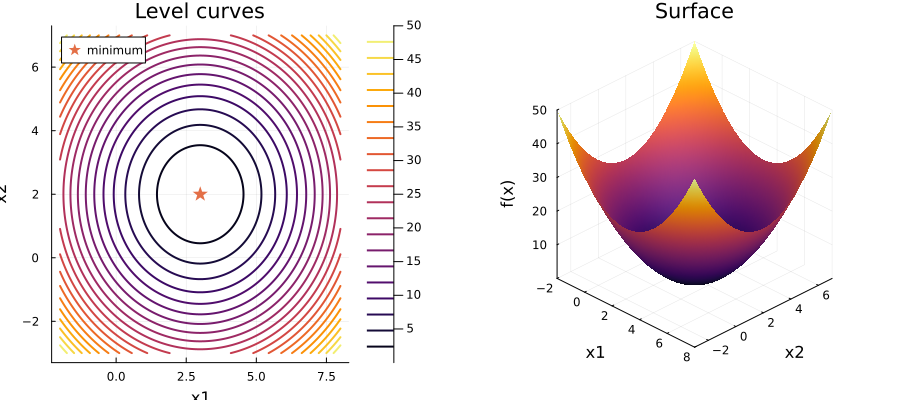

In [34]:
f_circ(x1, x2) = (x1 - 3)^2 + (x2 - 2)^2

x1_grid = range(-2, 8; length = 150)
x2_grid = range(-3, 7; length = 150)
Z_circ = [f_circ(a, b) for b in x2_grid, a in x1_grid]

p1 = contour(
    x1_grid,
    x2_grid,
    Z_circ;
    levels = 20,
    xlabel = "x1",
    ylabel = "x2",
    title = "Level curves",
    label = "",
)
scatter!(p1, [3], [2]; marker = :star, markersize = 8, label = "minimum")

p2 = surface(
    x1_grid,
    x2_grid,
    Z_circ;
    xlabel = "x1",
    ylabel = "x2",
    zlabel = "f(x)",
    title = "Surface",
    camera = (45, 30),
    legend = false,
)

plot(p1, p2; layout = (1, 2), size = (900, 400))

Starting from the point $x = [1.0, 1.0]$, implement the gradient descent and Newton method to find the minimum of this function.

In [35]:
function gradient_descent_bt(f, grad_f, x0; alpha = 0.4, beta = 0.5, tol = 1e-5, max_iter = 10_000)
    x = copy(x0)
    history = [copy(x)]

    for k in 1:max_iter
        g = grad_f(x)
        if norm(g) <= tol
            return x, f(x), k - 1, history
        end

        delta_x = -g
        t = 1.0

        while f(x + t * delta_x) > f(x) + alpha * t * dot(g, delta_x)
            t *= beta
        end

        x = x + t * delta_x
        push!(history, copy(x))
    end

    return x, f(x), max_iter, history
end

function newton_bt(f, grad_f, hess_f, x0; alpha = 0.4, beta = 0.5, tol = 1e-5, max_iter = 100)
    x = copy(x0)
    history = [copy(x)]

    for k in 1:max_iter
        g = grad_f(x)
        H = hess_f(x)

        delta_x = -H \ g
        lambda2 = dot(g, H \ g)

        if lambda2 / 2 <= tol
            return x, f(x), k - 1, history
        end

        t = 1.0
        while f(x + t * delta_x) > f(x) + alpha * t * dot(g, delta_x)
            t *= beta
        end

        x = x + t * delta_x
        push!(history, copy(x))
    end

    return x, f(x), max_iter, history
end

f1(x) = (x[1] - 3)^2 + (x[2] - 2)^2
grad_f1(x) = ForwardDiff.gradient(f1, x)
hess_f1(x) = ForwardDiff.hessian(f1, x)

x0 = [1.0, 1.0]

x_gd, fx_gd, it_gd, hist_gd = gradient_descent_bt(f1, grad_f1, x0)
x_nt, fx_nt, it_nt, hist_nt = newton_bt(f1, grad_f1, hess_f1, x0)

println("Gradient descent")
println("x* = ", x_gd)
println("f(x*) = ", fx_gd)
println("iterations = ", it_gd)

println()
println("Newton")
println("x* = ", x_nt)
println("f(x*) = ", fx_nt)
println("iterations = ", it_nt)

Gradient descent
x* = [3.0, 2.0]
f(x*) = 0.0
iterations = 1

Newton
x* = [3.0, 2.0]
f(x*) = 0.0
iterations = 1


Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2$

In [36]:
f2(x) = 10 * (x[1] - 3)^2 + 2 * (x[2] - 2)^2
grad_f2(x) = ForwardDiff.gradient(f2, x)
hess_f2(x) = ForwardDiff.hessian(f2, x)

x0 = [1.0, 1.0]

x_gd, fx_gd, it_gd, hist_gd = gradient_descent_bt(f2, grad_f2, x0)
x_nt, fx_nt, it_nt, hist_nt = newton_bt(f2, grad_f2, hess_f2, x0)

println("Gradient descent")
println("x* = ", x_gd)
println("f(x*) = ", fx_gd)
println("iterations = ", it_gd)

println()
println("Newton")
println("x* = ", x_nt)
println("f(x*) = ", fx_nt)
println("iterations = ", it_nt)

Gradient descent
x* = [2.999999864059845, 1.999998572628371]
f(x*) = 4.25957679170995e-12
iterations = 29

Newton
x* = [3.0, 2.0]
f(x*) = 0.0
iterations = 1


Now implement the same methods for the function $f(x) = x_1^2 + x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [37]:
f3(x) = x[1]^2 + x[2]^2
grad_f3(x) = ForwardDiff.gradient(f3, x)
hess_f3(x) = ForwardDiff.hessian(f3, x)

x0 = [-2.0, 2.0]

x_gd, fx_gd, it_gd, hist_gd = gradient_descent_bt(f3, grad_f3, x0)
x_nt, fx_nt, it_nt, hist_nt = newton_bt(f3, grad_f3, hess_f3, x0)

println("Gradient descent")
println("x* = ", x_gd)
println("f(x*) = ", fx_gd)
println("iterations = ", it_gd)

println()
println("Newton")
println("x* = ", x_nt)
println("f(x*) = ", fx_nt)
println("iterations = ", it_nt)

Gradient descent
x* = [0.0, 0.0]
f(x*) = 0.0
iterations = 1

Newton
x* = [0.0, 0.0]
f(x*) = 0.0
iterations = 1


Implement the same methods for the function $f(x) = x_1^2 + 100x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [38]:
f4(x) = x[1]^2 + 100 * x[2]^2
grad_f4(x) = ForwardDiff.gradient(f4, x)
hess_f4(x) = ForwardDiff.hessian(f4, x)

x0 = [-2.0, 2.0]

x_gd, fx_gd, it_gd, hist_gd = gradient_descent_bt(f4, grad_f4, x0)
x_nt, fx_nt, it_nt, hist_nt = newton_bt(f4, grad_f4, hess_f4, x0)

println("Gradient descent")
println("x* = ", x_gd)
println("f(x*) = ", fx_gd)
println("iterations = ", it_gd)

println()
println("Newton")
println("x* = ", x_nt)
println("f(x*) = ", fx_nt)
println("iterations = ", it_nt)

Gradient descent
x* = [-4.0437239972265555e-6, -2.0151199257165205e-8]
f(x*) = 1.639231084889611e-11
iterations = 554

Newton
x* = [0.0, 0.0]
f(x*) = 0.0
iterations = 1


For the last problem, perform the change of variables: $x_2 = \frac{1}{10}y_2$

In [39]:
# Change of variables for f(x) = x1^2 + 100*x2^2.
# With x2 = y2/10 and y1 = x1, the transformed function is
# g(y) = y1^2 + y2^2.

g_var(y) = y[1]^2 + y[2]^2
grad_g_var(y) = ForwardDiff.gradient(g_var, y)
hess_g_var(y) = ForwardDiff.hessian(g_var, y)

x0_original = [-2.0, 2.0]
y0 = [x0_original[1], 10 * x0_original[2]]

y_gd, gy_gd, it_gd, hist_gd_y = gradient_descent_bt(g_var, grad_g_var, y0)
y_nt, gy_nt, it_nt, hist_nt_y = newton_bt(g_var, grad_g_var, hess_g_var, y0)

x_gd_transformed = [y_gd[1], y_gd[2] / 10]
x_nt_transformed = [y_nt[1], y_nt[2] / 10]

println("With the change of variables x2 = y2/10")
println("Gradient descent in y: y* = ", y_gd, " -> x* = ", x_gd_transformed)
println("f(x*) = ", f4(x_gd_transformed))
println("iterations = ", it_gd)

println()
println("Newton in y: y* = ", y_nt, " -> x* = ", x_nt_transformed)
println("f(x*) = ", f4(x_nt_transformed))
println("iterations = ", it_nt)

With the change of variables x2 = y2/10
Gradient descent in y: y* = [0.0, 0.0] -> x* = [0.0, 0.0]
f(x*) = 0.0
iterations = 1

Newton in y: y* = [0.0, 0.0] -> x* = [0.0, 0.0]
f(x*) = 0.0
iterations = 1


##  Gradient Descent with Backtracking Line Search:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Define the function in the cell below:

In [40]:
function f_nonlin(x)
    x1, x2, x3 = x
    return x3 * log(exp(x1 / x3) + exp(x2 / x3)) + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

function in_domain(x)
    return (x[1] + x[2] > 0.0) && (x[3] > 0.0) && all(isfinite, x)
end

x_test = [3.0, 4.0, 5.0]
println("f([3, 4, 5]) = ", f_nonlin(x_test))
println("In domain? ", in_domain(x_test))

f([3, 4, 5]) = 17.144259341803068
In domain? true


Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

#### implement the first derivative 

In [41]:
function grad_f_nonlin(x)
    x1, x2, x3 = x
    e1 = exp(x1 / x3)
    e2 = exp(x2 / x3)
    s = e1 + e2
    c = exp(1 / (x1 + x2))

    return [
        e1 / s - c / (x1 + x2)^2,
        e2 / s - c / (x1 + x2)^2,
        log(s) - (x1 * e1 + x2 * e2) / (x3 * s) + 2 * (x3 - 2),
    ]
end

println("grad f([3, 4, 5]) = ", grad_f_nonlin([3.0, 4.0, 5.0]))

grad f([3, 4, 5]) = [0.42662385993456065, 0.5262918545595165, 6.688172069919096]


Defining parameters for backtracking search: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$

In [42]:
alpha = 0.4
beta = 0.5
tol = 1e-5

println("alpha = ", alpha)
println("beta = ", beta)
println("tol = ", tol)

alpha = 0.4
beta = 0.5
tol = 1.0e-5


Start Point: [3.0, 4.0, 5.0]

In [43]:
x0 = [3.0, 4.0, 5.0]
println("Start point x0 = ", x0)

Start point x0 = [3.0, 4.0, 5.0]


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where, $\Delta x = -\nabla f(x)$

In [44]:
function ensure_domain(x, delta_x; beta = 0.5, max_shrinks = 200)
    t = 1.0
    shrinks = 0

    while !in_domain(x + t * delta_x)
        t *= beta
        shrinks += 1
        shrinks > max_shrinks && error("Could not find a step inside the domain.")
    end

    return t
end

delta_x = -grad_f_nonlin(x0)
t_dom = ensure_domain(x0, delta_x; beta = beta)

println("Direction delta_x = ", delta_x)
println("Step after ensuring domain = ", t_dom)
println("New point = ", x0 + t_dom * delta_x)
println("In domain? ", in_domain(x0 + t_dom * delta_x))

Direction delta_x = [-0.42662385993456065, -0.5262918545595165, -6.688172069919096]
Step after ensuring domain = 0.5
New point = [2.78668807003272, 3.7368540727202415, 1.655913965040452]
In domain? true


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [45]:
function backtracking_nonlin(f, grad_f, in_domain, x, delta_x; alpha = 0.4, beta = 0.5, max_iter = 200)
    t = ensure_domain(x, delta_x; beta = beta, max_shrinks = max_iter)
    g = grad_f(x)
    fx = f(x)

    for _ in 1:max_iter
        if f(x + t * delta_x) <= fx + alpha * t * dot(g, delta_x)
            return t
        end
        t *= beta
    end

    error("Backtracking did not satisfy the sufficient decrease condition.")
end

t_bt = backtracking_nonlin(f_nonlin, grad_f_nonlin, in_domain, x0, delta_x; alpha = alpha, beta = beta)
println("Backtracking step = ", t_bt)
println("New point = ", x0 + t_bt * delta_x)

Backtracking step = 0.5
New point = [2.78668807003272, 3.7368540727202415, 1.655913965040452]


### Algorithm: Gradient Descent

1. **Input:** Starting point $x$ in $\text{dom} \, f$

2. **Repeat until stopping criterion is satisfied:**

    a. $\Delta x := -\nabla f(x)$
    
    b. **Line search:** Choose step size $t$ via backtracking line search
    
    c. **Update:** $x := x + t \Delta x$

In [46]:
function gradient_descent_nonlin(x0; alpha = 0.4, beta = 0.5, tol = 1e-5, max_iter = 10_000)
    x = copy(x0)
    history = [copy(x)]

    for k in 1:max_iter
        g = grad_f_nonlin(x)

        if norm(g) <= tol
            return x, f_nonlin(x), k - 1, history
        end

        delta_x = -g
        t = backtracking_nonlin(f_nonlin, grad_f_nonlin, in_domain, x, delta_x; alpha = alpha, beta = beta)

        x = x + t * delta_x
        push!(history, copy(x))
    end

    return x, f_nonlin(x), max_iter, history
end

x_gd, f_gd, it_gd, hist_gd = gradient_descent_nonlin(x0; alpha = alpha, beta = beta, tol = tol)

println("Gradient descent with backtracking")
println("x* = ", x_gd)
println("f(x*) = ", f_gd)
println("grad f(x*) = ", grad_f_nonlin(x_gd))
println("norm(grad f(x*)) = ", norm(grad_f_nonlin(x_gd)))
println("iterations = ", it_gd)

Gradient descent with backtracking
x* = [0.9261872701983407, 0.9262296480441212, 1.6534264097600675]
f(x*) = 3.908113786397637
grad f(x*) = [-6.40758107955941e-6, 6.407578255096524e-6, -2.0335955142058992e-12]
norm(grad f(x*)) = 9.061686067521745e-6
iterations = 30


## Optimisation using Newton's Method:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [47]:
function hess_f_nonlin(x)
    return ForwardDiff.jacobian(grad_f_nonlin, x)
end

println("Hessian at x0:")
display(hess_f_nonlin(x0))

3×3 Matrix{Float64}:
  0.0567101   -0.0422965    0.00990066
 -0.0422965    0.0567101   -0.00990066
  0.00990066  -0.00990066   2.00198

Hessian at x0:


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [48]:
alpha = 0.4
beta = 0.5
tol = 1e-5
x0 = [3.0, 4.0, 5.0]

println("alpha = ", alpha, ", beta = ", beta, ", tol = ", tol)
println("x0 = ", x0)

alpha = 0.4, beta = 0.5, tol = 1.0e-5
x0 = [3.0, 4.0, 5.0]


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where
$\Delta x = -\nabla^2 f(x)^{-1} \nabla f(x)$

In [49]:
g0 = grad_f_nonlin(x0)
H0 = hess_f_nonlin(x0)
delta_x_nt = -H0 \ g0
t_dom_nt = ensure_domain(x0, delta_x_nt; beta = beta)

println("Newton direction delta_x = ", delta_x_nt)
println("Step after ensuring domain = ", t_dom_nt)
println("New point = ", x0 + t_dom_nt * delta_x_nt)
println("In domain? ", in_domain(x0 + t_dom_nt * delta_x_nt))

Newton direction delta_x = [-32.217983671848, -33.894477571491635, -3.3490694346907968]
Step after ensuring domain = 0.0625
New point = [0.9863760205094998, 1.8815951517817728, 4.790683160331826]
In domain? true


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla^2 f(x)^{-1} \nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [50]:
t_nt = backtracking_nonlin(f_nonlin, grad_f_nonlin, in_domain, x0, delta_x_nt; alpha = alpha, beta = beta)

println("Newton backtracking step = ", t_nt)
println("New point = ", x0 + t_nt * delta_x_nt)

Newton backtracking step = 0.0625
New point = [0.9863760205094998, 1.8815951517817728, 4.790683160331826]


# code

### Newton's Algorithm

**Input:** (defined earlier)
- Starting point $x \in \text{dom} \, f$
- Tolerance $\varepsilon > 0$

**Repeat:**
1. Compute the Newton step and decrement.
   $
   \Delta x_{nt} := -\nabla^2 f(x)^{-1}\nabla f(x); \quad \lambda^2 := \nabla f(x)^T \nabla^2 f(x)^{-1}\nabla f(x)
   $
2. Stopping criterion. $\textbf{quit}$ if $\lambda^2/2 \leq \varepsilon.$
3. Line search. Choose step size $t$ by backtracking line search; ensuring update $ := x + t \Delta x$ lies in $\mathbf{dom} f$ throughout.
4. Update. $x := x + t\Delta x_{nt}$.

In [51]:
function newton_nonlin(x0; alpha = 0.4, beta = 0.5, tol = 1e-5, max_iter = 100)
    x = copy(x0)
    history = [copy(x)]

    for k in 1:max_iter
        g = grad_f_nonlin(x)
        H = hess_f_nonlin(x)

        delta_x = -H \ g
        lambda2 = dot(g, H \ g)

        if lambda2 / 2 <= tol
            return x, f_nonlin(x), k - 1, history
        end

        t = backtracking_nonlin(f_nonlin, grad_f_nonlin, in_domain, x, delta_x; alpha = alpha, beta = beta)

        x = x + t * delta_x
        push!(history, copy(x))
    end

    return x, f_nonlin(x), max_iter, history
end

x_nt, f_nt, it_nt, hist_nt = newton_nonlin(x0; alpha = alpha, beta = beta, tol = tol)

println("Newton method")
println("x* = ", x_nt)
println("f(x*) = ", f_nt)
println("grad f(x*) = ", grad_f_nonlin(x_nt))
println("norm(grad f(x*)) = ", norm(grad_f_nonlin(x_nt)))
println("iterations = ", it_nt)

Newton method
x* = [0.9259801588949453, 0.9260041301052008, 1.653301625909102]
f(x*) = 3.9081138660512487
grad f(x*) = [-0.00030034215272323195, -0.0002930926557532798, -0.00024956764812822385]
norm(grad f(x*)) = 0.00048825477422262723
iterations = 4


## Optimisation using Quasi-Newton Method:
### The Broyden-Fletcher-Goldfarb-Shanno (BFGS) update
  

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [52]:
# For BFGS we reuse f_nonlin, grad_f_nonlin, in_domain and backtracking_nonlin.
println("Function, gradient, domain check and backtracking are already defined.")

Function, gradient, domain check and backtracking are already defined.


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [53]:
alpha = 0.4
beta = 0.5
tol = 1e-5
x0 = [3.0, 4.0, 5.0]

println("alpha = ", alpha, ", beta = ", beta, ", tol = ", tol)
println("x0 = ", x0)

alpha = 0.4, beta = 0.5, tol = 1.0e-5
x0 = [3.0, 4.0, 5.0]


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ 

Here, the direction $\Delta x$ has been taken as a parameter in the defined function and thus we need not explicitly calculate it again.

In [54]:
test_direction = -grad_f_nonlin(x0)
t_domain_bfgs = ensure_domain(x0, test_direction; beta = beta)

println("Step that keeps the domain = ", t_domain_bfgs)
println("New x = ", x0 + t_domain_bfgs * test_direction)

Step that keeps the domain = 0.5
New x = [2.78668807003272, 3.7368540727202415, 1.655913965040452]


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x  \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [55]:
p_test = -grad_f_nonlin(x0)
t_test = backtracking_nonlin(f_nonlin, grad_f_nonlin, in_domain, x0, p_test; alpha = alpha, beta = beta)

println("Backtracking step = ", t_test)

Backtracking step = 0.5


### Running the BFGS Algorithm: 

**Given:**
- Starting point $x_0$
- Convergence tolerance $\epsilon > 0$ $(=10^{-5})$
- Starting matrix $H_0$ (taken as Identity matrix)
  
**Initialization:** $k \gets 0$

**While:** $\| \nabla f_k \| > \epsilon$
1. Compute search direction by solving:
   $ p_k = - H_k \nabla f_k $
2. Set $x_{k+1} = x_k + \alpha_k p_k$, where $\alpha_k$ is computed from backtracking line search procedure.
3. Define $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$.
4. Compute $H_{k+1}$ using BFGS.
5. $k \gets k + 1$

Finally, as mentioned in the implementation note to set $\rho_k $ as a constant after $y^T_k s_k$ gets smaller some certain $\epsilon$ say $10^{-5}$.\
We have used an $\epsilon = 10^{-4}$ and set the value for  $\rho_k = 10^{4}$.


In [56]:
function bfgs_nonlin(x0; alpha = 0.4, beta = 0.5, tol = 1e-5, max_iter = 500)
    x = copy(x0)
    n = length(x)
    H = Matrix{Float64}(I, n, n)
    history = [copy(x)]

    for k in 1:max_iter
        g = grad_f_nonlin(x)

        if norm(g) <= tol
            return x, f_nonlin(x), k - 1, history
        end

        p = -H * g

        if dot(g, p) >= 0
            H = Matrix{Float64}(I, n, n)
            p = -g
        end

        t = backtracking_nonlin(f_nonlin, grad_f_nonlin, in_domain, x, p; alpha = alpha, beta = beta)

        x_new = x + t * p
        s = x_new - x
        y = grad_f_nonlin(x_new) - g
        ys = dot(y, s)

        if ys > 1e-10
            rho = 1 / ys
            V = Matrix{Float64}(I, n, n) - rho * s * y'
            H = V * H * V' + rho * (s * s')
        else
            H = Matrix{Float64}(I, n, n)
        end

        x = x_new
        push!(history, copy(x))
    end

    return x, f_nonlin(x), max_iter, history
end

x_bfgs, f_bfgs, it_bfgs, hist_bfgs = bfgs_nonlin(x0; alpha = alpha, beta = beta, tol = tol)

println("BFGS method")
println("x* = ", x_bfgs)
println("f(x*) = ", f_bfgs)
println("grad f(x*) = ", grad_f_nonlin(x_bfgs))
println("norm(grad f(x*)) = ", norm(grad_f_nonlin(x_bfgs)))
println("iterations = ", it_bfgs)

BFGS method
x* = [0.9262108201941381, 0.9262107344070645, 1.6534258875113628]
f(x*) = 3.9081137862695075
grad f(x*) = [3.191393537604892e-6, 3.1654513183987376e-6, -1.0444173296209058e-6]
norm(grad f(x*)) = 4.614746181474236e-6
iterations = 11


# Problem Statement: Optimal Control for CSTR

We are given the liearized discrete state space model, time horizon, initial state, setpoints for controlled variables, and variable bounds 

In [57]:
using JuMP
using HiGHS
using LinearAlgebra
using Plots

println("Packages for the CSTR problem loaded.")

Packages for the CSTR problem loaded.


#### Defining state space model, time horizon, initial state, and variable bounds

Note: since it is assumed that all the states are measurable without noise, here the controlled variables are represented using x instead for simplicity

Hints: use matrix A, B from material. Time horizon = 3; Initial condition: [-0.03, 0.0, 0.3]; bounds: xmax = [0.05, 5, 0.5]; xmin = [-0.05, -5, -0.5]; umax = [10, 0.05]; umin = [-10, -0.05]

In [58]:
# Linear discrete CSTR model.
A = [
    0.2681  -0.00338   -0.00728;
    9.703    0.3279   -25.44;
    0.0      0.0        1.0
]

B = [
    -0.00537    0.1655;
     1.297     97.91;
     0.0       -6.637
]

# All states are measured, so C is the identity matrix.
C = [
    1.0  0.0  0.0;
    0.0  1.0  0.0;
    0.0  0.0  1.0
]

N = 3
nx = 3
nu = 2
ny = 3

x0_cstr = [-0.03, 0.0, 0.3]

xmin = [-0.05, -5.0, -0.5]
xmax = [ 0.05,  5.0,  0.5]

umin = [-10.0, -0.05]
umax = [ 10.0,  0.05]

println("A = ")
display(A)
println("B = ")
display(B)
println("C = ")
display(C)

3×3 Matrix{Float64}:
 0.2681  -0.00338   -0.00728
 9.703    0.3279   -25.44
 0.0      0.0        1.0

3×2 Matrix{Float64}:
 -0.00537   0.1655
  1.297    97.91
  0.0      -6.637

3×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

A = 
B = 
C = 


## Model

The LP model for the problem can be derived as follows:


\begin{aligned}
\min_{u(0),u(1),u(2)} \quad &\sum_{k=0}^{k=3} (z_1(k)+z_2(k)) \\
\textit{s.t.} \quad &{x}(k+1) ={A} {x}(k)+{B u}(k) \quad k=0,1,2 \\
&y(k) ={C} {x}(k) \quad k=0,1,2,3 \\
&{x}(0) = \begin{bmatrix}
-0.03 \\
0 \\
0.3
\end{bmatrix} \\
&\begin{bmatrix}
-0.05 \\
-5 \\
-0.5
\end{bmatrix} 
\leq x(k) \leq 
\begin{bmatrix}
0.05 \\
5 \\
0.5
\end{bmatrix} \quad k=0,1,2,3 \\
&\begin{bmatrix}
-10 \\
-0.05
\end{bmatrix} 
\leq u(k) \leq 
\begin{bmatrix}
10 \\
0.05
\end{bmatrix} \quad k=0,1,2 \\
&-z_1(k) \leq y_1(k) \leq z_1(k) \quad k=0,1,2,3 \\
&-z_2(k) \leq y_3(k) \leq z_2(k) \quad k=0,1,2,3 \\
\end{aligned}



## Implement

In [59]:
model_cstr = Model(HiGHS.Optimizer)
set_silent(model_cstr)

@variable(model_cstr, xmin[i] <= x[i = 1:nx, k = 0:N] <= xmax[i])
@variable(model_cstr, umin[i] <= u[i = 1:nu, k = 0:N-1] <= umax[i])
@variable(model_cstr, y[1:ny, 0:N])
@variable(model_cstr, z1[0:N] >= 0)
@variable(model_cstr, z2[0:N] >= 0)

@constraint(model_cstr, [i = 1:nx], x[i, 0] == x0_cstr[i])

@constraint(model_cstr, [i = 1:nx, k = 0:N-1],
    x[i, k+1] == sum(A[i, j] * x[j, k] for j in 1:nx) +
                 sum(B[i, j] * u[j, k] for j in 1:nu)
)

@constraint(model_cstr, [i = 1:ny, k = 0:N],
    y[i, k] == sum(C[i, j] * x[j, k] for j in 1:nx)
)

@constraint(model_cstr, [k = 0:N], -z1[k] <= y[1, k])
@constraint(model_cstr, [k = 0:N],  y[1, k] <= z1[k])
@constraint(model_cstr, [k = 0:N], -z2[k] <= y[3, k])
@constraint(model_cstr, [k = 0:N],  y[3, k] <= z2[k])

@objective(model_cstr, Min, sum(z1[k] + z2[k] for k in 0:N))

println("CSTR LP model created.")
println(model_cstr)

CSTR LP model created.
Min z1[0] + z2[0] + z1[1] + z2[1] + z1[2] + z2[2] + z1[3] + z2[3]
Subject to
 x[1,0] == -0.03
 x[2,0] == 0
 x[3,0] == 0.3
 -0.2681 x[1,0] + 0.00338 x[2,0] + 0.00728 x[3,0] + x[1,1] + 0.00537 u[1,0] - 0.1655 u[2,0] == 0
 -9.703 x[1,0] - 0.3279 x[2,0] + 25.44 x[3,0] + x[2,1] - 1.297 u[1,0] - 97.91 u[2,0] == 0
 -x[3,0] + x[3,1] + 6.637 u[2,0] == 0
 -0.2681 x[1,1] + 0.00338 x[2,1] + 0.00728 x[3,1] + x[1,2] + 0.00537 u[1,1] - 0.1655 u[2,1] == 0
 -9.703 x[1,1] - 0.3279 x[2,1] + 25.44 x[3,1] + x[2,2] - 1.297 u[1,1] - 97.91 u[2,1] == 0
 -x[3,1] + x[3,2] + 6.637 u[2,1] == 0
 -0.2681 x[1,2] + 0.00338 x[2,2] + 0.00728 x[3,2] + x[1,3] + 0.00537 u[1,2] - 0.1655 u[2,2] == 0
 -9.703 x[1,2] - 0.3279 x[2,2] + 25.44 x[3,2] + x[2,3] - 1.297 u[1,2] - 97.91 u[2,2] == 0
 -x[3,2] + x[3,3] + 6.637 u[2,2] == 0
 -x[1,0] + y[1,0] == 0
 -x[2,0] + y[2,0] == 0
 -x[3,0] + y[3,0] == 0
 -x[1,1] + y[1,1] == 0
 -x[2,1] + y[2,1] == 0
 -x[3,1] + y[3,1] == 0
 -x[1,2] + y[1,2] == 0
 -x[2,2] + y[2,2] =

## Solve and Postprocess

Termination status: OPTIMAL
Primal status: FEASIBLE_POINT
Objective value: 0.32999999999999996

States x(k):
k = 0 -> [-0.03, -0.0, 0.3]
k = 1 -> [-0.0, -4.160729869009271, -0.0]
k = 2 -> [-0.0, 2.0323553805244825, -0.0]
k = 3 -> [-0.0, -0.9927268827308746, -0.0]

Inputs u(k):
k = 0 -> [-0.5113986008688383, 0.04520114509567576]
k = 1 -> [2.618857906378275, -0.0]
k = 2 -> [-1.2792106491941808, -0.0]


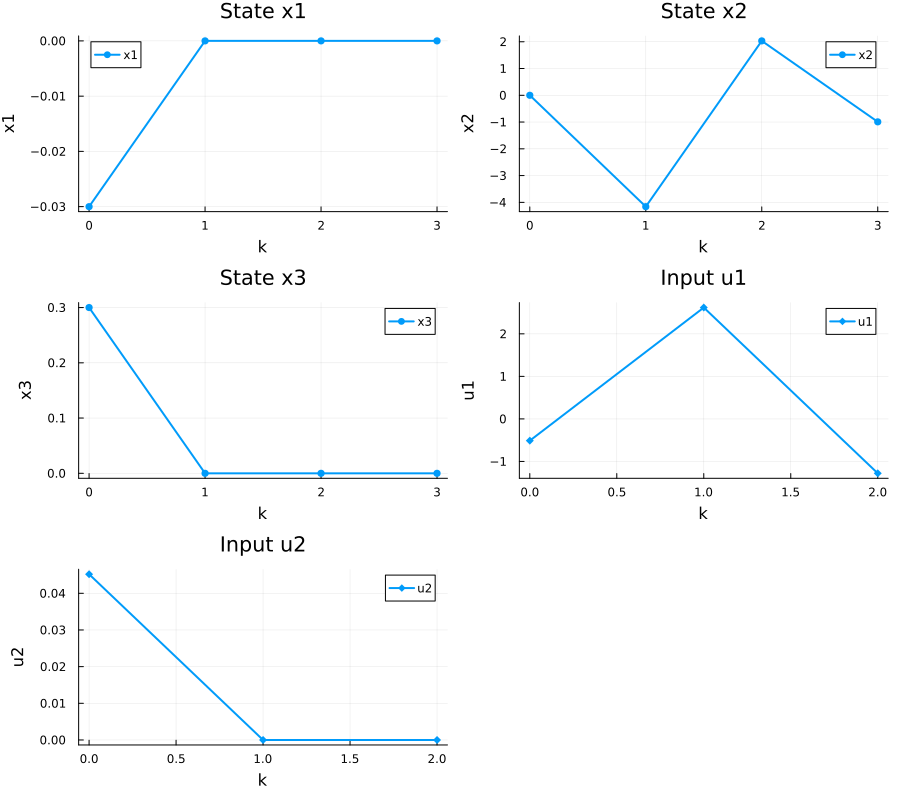

In [60]:
optimize!(model_cstr)

println("Termination status: ", termination_status(model_cstr))
println("Primal status: ", primal_status(model_cstr))
println("Objective value: ", objective_value(model_cstr))

x_sol = value.(x)
u_sol = value.(u)
y_sol = value.(y)

println()
println("States x(k):")
for k in 0:N
    println("k = ", k, " -> ", [x_sol[i, k] for i in 1:nx])
end

println()
println("Inputs u(k):")
for k in 0:N-1
    println("k = ", k, " -> ", [u_sol[i, k] for i in 1:nu])
end

time_x = 0:N
time_u = 0:N-1

p_x1 = plot(time_x, [x_sol[1, k] for k in time_x]; marker = :circle, xlabel = "k", ylabel = "x1", title = "State x1", label = "x1")
p_x2 = plot(time_x, [x_sol[2, k] for k in time_x]; marker = :circle, xlabel = "k", ylabel = "x2", title = "State x2", label = "x2")
p_x3 = plot(time_x, [x_sol[3, k] for k in time_x]; marker = :circle, xlabel = "k", ylabel = "x3", title = "State x3", label = "x3")
p_u1 = plot(time_u, [u_sol[1, k] for k in time_u]; marker = :diamond, xlabel = "k", ylabel = "u1", title = "Input u1", label = "u1")
p_u2 = plot(time_u, [u_sol[2, k] for k in time_u]; marker = :diamond, xlabel = "k", ylabel = "u2", title = "Input u2", label = "u2")

plot(p_x1, p_x2, p_x3, p_u1, p_u2; layout = (3, 2), size = (900, 800))